In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/Copy of sonar data (1).csv')
df

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
0,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
1,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
2,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
3,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
4,0.0286,0.0453,0.0277,0.0174,0.0384,0.0990,0.1201,0.1833,0.2105,0.3039,...,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157,M
203,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067,M
204,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031,M
205,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,M


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}\n")

# Initialize and train a Logistic Regression model
model = LogisticRegression(max_iter=200)
print("Training Logistic Regression model...")
model.fit(X_train, y_train)
print("Model training complete.\n")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(report)

X_train shape: (165, 60)
X_test shape: (42, 60)
y_train shape: (165,)
y_test shape: (42,)

Training Logistic Regression model...
Model training complete.

Model Accuracy: 0.76

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.67      0.78        27
           1       0.61      0.93      0.74        15

    accuracy                           0.76        42
   macro avg       0.78      0.80      0.76        42
weighted avg       0.83      0.76      0.77        42



In [6]:
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Filled missing values in '{col}' with mode: {mode_val}")

In [7]:
print("Filling missing values...")

# Fill categorical columns with mode
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Filled missing values in categorical column '{col}' with mode: {mode_val}")

# Fill numerical columns with mean (if any nulls are present)
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    if df[col].isnull().any():
        mean_val = df[col].mean()
        df[col] = df[col].fillna(mean_val)
        print(f"Filled missing values in numerical column '{col}' with mean: {mean_val:.2f}")

print("\nMissing values after imputation:")
df.isnull().sum()

Filling missing values...

Missing values after imputation:


,0
0.0200,0
0.0371,0
0.0428,0
0.0207,0
0.0954,0
...,...
0.0180,0
0.0084,0
0.0090,0
0.0032,0


In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
label_encoders = {}
for column in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

print(df.head())

   0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109  \
0  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
1  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
2  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
3  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   
4  0.0286  0.0453  0.0277  0.0174  0.0384  0.0990  0.1201  0.1833  0.2105   

   0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084  \
0  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
1  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
2  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
3  0.4459  ...  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072  0.0048   
4  0.3039  ...  0.0045  0.0014  0.0038  0.0013  0.0089  0.0057  0.0027   

   0.0090  0.0032  R  
0  0.0052  0.0044  1  
1  0.0095  0.0078  1  
2  0.0040  0.0117  1  


In [11]:
X = df.drop('R', axis=1)
y = df['R']

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

Shape of X (features): (207, 60)
Shape of y (target): (207,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (165, 60)
Shape of X_test: (42, 60)
Shape of y_train: (165,)
Shape of y_test: (42,)


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

 Linear Regression

In [15]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = mse_linear**0.5
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression - MAE: {mae_linear:.2f}")
print(f"Linear Regression - MSE: {mse_linear:.2f}")
print(f"Linear Regression - RMSE: {rmse_linear:.2f}")
print(f"Linear Regression - R2 Score: {r2_linear:.2f}")

Linear Regression - MAE: 0.37
Linear Regression - MSE: 0.22
Linear Regression - RMSE: 0.47
Linear Regression - R2 Score: 0.05


In [16]:
# SVR can be computationally expensive on large datasets. We'll use a linear kernel for simplicity.
# For better performance on larger datasets, consider using StandardScaler on features.
svr_model = SVR(kernel='linear')
svr_model.fit(X_train, y_train)

y_pred_svr = svr_model.predict(X_test)

mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = mse_svr**0.5
r2_svr = r2_score(y_test, y_pred_svr)

print(f"SVR - MAE: {mae_svr:.2f}")
print(f"SVR - MSE: {mse_svr:.2f}")
print(f"SVR - RMSE: {rmse_svr:.2f}")
print(f"SVR - R2 Score: {r2_svr:.2f}")

SVR - MAE: 0.35
SVR - MSE: 0.20
SVR - RMSE: 0.44
SVR - R2 Score: 0.14


K-Nearest Neighbors (KNN) Regressor

In [17]:
knn_model = KNeighborsRegressor(n_neighbors=5) # You can adjust n_neighbors
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = mse_knn**0.5
r2_knn = r2_score(y_test, y_pred_knn)

print(f"KNN Regressor - MAE: {mae_knn:.2f}")
print(f"KNN Regressor - MSE: {mse_knn:.2f}")
print(f"KNN Regressor - RMSE: {rmse_knn:.2f}")
print(f"KNN Regressor - R2 Score: {r2_knn:.2f}")

KNN Regressor - MAE: 0.35
KNN Regressor - MSE: 0.24
KNN Regressor - RMSE: 0.49
KNN Regressor - R2 Score: -0.03


Decision Tree Regressor

In [18]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = mse_dt**0.5
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree Regressor - MAE: {mae_dt:.2f}")
print(f"Decision Tree Regressor - MSE: {mse_dt:.2f}")
print(f"Decision Tree Regressor - RMSE: {rmse_dt:.2f}")
print(f"Decision Tree Regressor - R2 Score: {r2_dt:.2f}")

Decision Tree Regressor - MAE: 0.38
Decision Tree Regressor - MSE: 0.38
Decision Tree Regressor - RMSE: 0.62
Decision Tree Regressor - R2 Score: -0.66


Random Forest Regressor

Random Forest Regressor - MAE: 0.31
Random Forest Regressor - MSE: 0.15
Random Forest Regressor - RMSE: 0.39
Random Forest Regressor - R2 Score: 0.35


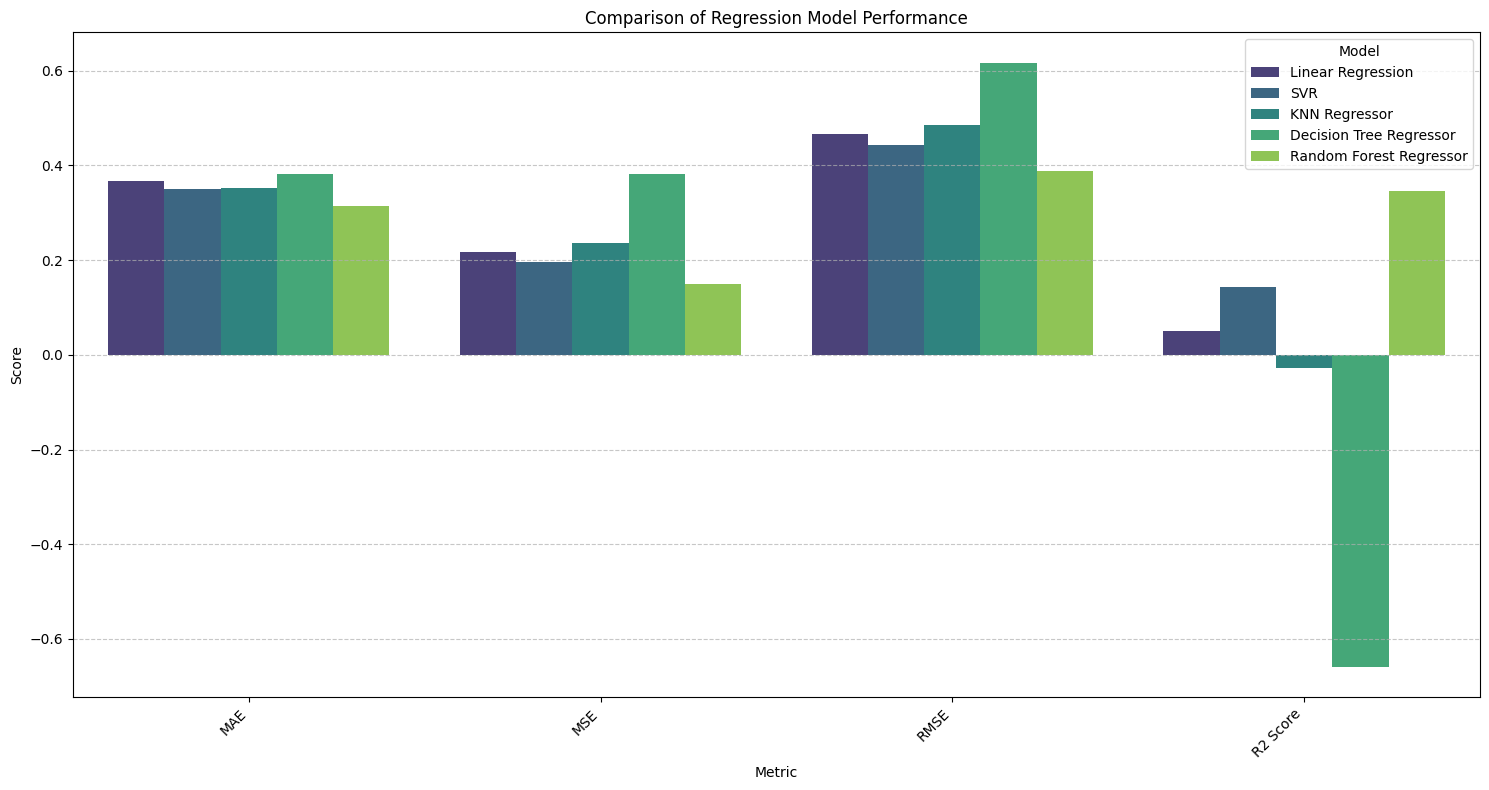


Regression Model Performance Summary:


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.367558,0.217965,0.466867,0.050641
1,SVR,0.349388,0.196879,0.443711,0.142482
2,KNN Regressor,0.352381,0.236190,0.485994,-0.028741
3,Decision Tree Regressor,0.380952,0.380952,0.617213,-0.659259
4,Random Forest Regressor,0.314286,0.150338,0.387735,0.345194


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf**0.5
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor - MAE: {mae_rf:.2f}")
print(f"Random Forest Regressor - MSE: {mse_rf:.2f}")
print(f"Random Forest Regressor - RMSE: {rmse_rf:.2f}")
print(f"Random Forest Regressor - R2 Score: {r2_rf:.2f}")

# Collect metrics for regression models
regression_metrics = {
    'Model': ['Linear Regression', 'SVR', 'KNN Regressor', 'Decision Tree Regressor', 'Random Forest Regressor'],
    'MAE': [mae_linear, mae_svr, mae_knn, mae_dt, mae_rf],
    'MSE': [mse_linear, mse_svr, mse_knn, mse_dt, mse_rf],
    'RMSE': [rmse_linear, rmse_svr, rmse_knn, rmse_dt, rmse_rf],
    'R2 Score': [r2_linear, r2_svr, r2_knn, r2_dt, r2_rf]
}

metrics_df = pd.DataFrame(regression_metrics)
metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(15, 8))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_df_melted, palette='viridis')
plt.title('Comparison of Regression Model Performance')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nRegression Model Performance Summary:")
display(metrics_df)

### Regression Model Comparison Analysis

Based on the performance metrics (MAE, MSE, RMSE, R2 Score), we can now analyze which model performed best for this regression task. Generally, lower MAE, MSE, and RMSE indicate better performance, while a higher R2 Score (closer to 1) suggests a better fit to the data.

In [21]:
# Identify the best performing model based on RMSE
best_model_rmse = metrics_df.loc[metrics_df['RMSE'].idxmin()]

print("Model with the lowest RMSE (best performing):")
display(best_model_rmse)

# Optionally, identify best model based on MAE as well
best_model_mae = metrics_df.loc[metrics_df['MAE'].idxmin()]
print("\nModel with the lowest MAE:")
display(best_model_mae)

Model with the lowest RMSE (best performing):


,4
Model,Random Forest Regressor
MAE,0.314286
MSE,0.150338
RMSE,0.387735
R2 Score,0.345194



Model with the lowest MAE:


,4
Model,Random Forest Regressor
MAE,0.314286
MSE,0.150338
RMSE,0.387735
R2 Score,0.345194


### Next Steps

Given the performance of these models, you might consider:

1.  **Hyperparameter Tuning:** Optimizing the hyperparameters of the best performing model(s) to further improve their performance.
2.  **Feature Engineering:** Creating new features or transforming existing ones to provide more information to the models.
3.  **Cross-Validation:** Using k-fold cross-validation for a more robust evaluation of model performance.
4.  **Ensemble Methods:** Exploring other ensemble techniques beyond Random Forest, like Gradient Boosting.
5.  **Addressing Data Scale:** If the features are on very different scales, applying a `StandardScaler` or `MinMaxScaler` could help models like SVR and Linear Regression perform better.

DOWNLOAD PKL MODEL

In [22]:
import pickle
from google.colab import files

# Save the Linear Regression model as a PKL file
model_filename = 'linear_regression_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(linear_model, file)

print(f"Model saved as {model_filename}")

# Provide a link to download the file
files.download(model_filename)

Model saved as linear_regression_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
import pickle
from google.colab import files

# 'label_encoders' is available in your current Colab kernel state
with open('label_encoders.pkl', 'wb') as file:
    pickle.dump(label_encoders, file)

print("Label encoders saved as label_encoders.pkl")
files.download('label_encoders.pkl')

Label encoders saved as label_encoders.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
app_py_content = """import streamlit as st
import pickle
import pandas as pd
import numpy as np

# Load the model and label encoders
try:
    with open('linear_regression_model.pkl', 'rb') as file:
        model = pickle.load(file)
    with open('label_encoders.pkl', 'rb') as file:
        label_encoders = pickle.load(file)
except FileNotFoundError:
    st.error("Model or label encoders not found. Please ensure 'linear_regression_model.pkl' and 'label_encoders.pkl' are in the same directory.")
    st.stop()

st.title('Salary Prediction App')
st.write('Enter the details to predict the salary.')

# Helper function to get original labels from encoder
def get_original_labels(encoder):
    if hasattr(encoder, 'classes_'):
        return list(encoder.classes_)
    return []

# Create input fields for each feature
# Assuming the order of features as in X: 'Rating', 'Company Name', 'Job Title', 'Salaries Reported', 'Location', 'Employment Status', 'Job Roles'

rating = st.slider('Rating', min_value=0.0, max_value=5.0, value=3.5, step=0.1)
salaries_reported = st.number_input('Salaries Reported', min_value=1, value=5, step=1)

company_name_options = get_original_labels(label_encoders.get('Company Name', None))
if company_name_options:
    company_name_display = st.selectbox('Company Name', options=company_name_options)
    company_name_encoded = label_encoders['Company Name'].transform([company_name_display])[0]
else:
    st.warning("Company Name encoder not found or has no classes. Please ensure label_encoders.pkl is correct.")
    company_name_encoded = st.number_input('Company Name (encoded)', value=0, help="Enter the numerical encoding if original labels are not available.")

job_title_options = get_original_labels(label_encoders.get('Job Title', None))
if job_title_options:
    job_title_display = st.selectbox('Job Title', options=job_title_options)
    job_title_encoded = label_encoders['Job Title'].transform([job_title_display])[0]
else:
    st.warning("Job Title encoder not found or has no classes. Please ensure label_encoders.pkl is correct.")
    job_title_encoded = st.number_input('Job Title (encoded)', value=0, help="Enter the numerical encoding if original labels are not available.")

location_options = get_original_labels(label_encoders.get('Location', None))
if location_options:
    location_display = st.selectbox('Location', options=location_options)
    location_encoded = label_encoders['Location'].transform([location_display])[0]
else:
    st.warning("Location encoder not found or has no classes. Please ensure label_encoders.pkl is correct.")
    location_encoded = st.number_input('Location (encoded)', value=0, help="Enter the numerical encoding if original labels are not available.")

employment_status_options = get_original_labels(label_encoders.get('Employment Status', None))
if employment_status_options:
    employment_status_display = st.selectbox('Employment Status', options=employment_status_options)
    employment_status_encoded = label_encoders['Employment Status'].transform([employment_status_display])[0]
else:
    st.warning("Employment Status encoder not found or has no classes. Please ensure label_encoders.pkl is correct.")
    employment_status_encoded = st.number_input('Employment Status (encoded)', value=0, help="Enter the numerical encoding if original labels are not available.")

job_roles_options = get_original_labels(label_encoders.get('Job Roles', None))
if job_roles_options:
    job_roles_display = st.selectbox('Job Roles', options=job_roles_options)
    job_roles_encoded = label_encoders['Job Roles'].transform([job_roles_display])[0]
else:
    st.warning("Job Roles encoder not found or has no classes. Please ensure label_encoders.pkl is correct.")
    job_roles_encoded = st.number_input('Job Roles (encoded)', value=0, help="Enter the numerical encoding if original labels are not available.")


if st.button('Predict Salary'):
    # Create a DataFrame for prediction
    input_data = pd.DataFrame([[
        rating,
        company_name_encoded,
        job_title_encoded,
        salaries_reported,
        location_encoded,
        employment_status_encoded,
        job_roles_encoded
    ]],
    columns=['Rating', 'Company Name', 'Job Title', 'Salaries Reported',
             'Location', 'Employment Status', 'Job Roles'])

    prediction = model.predict(input_data)[0]
    st.success(f'Predicted Salary: ₹{prediction:,.2f}')
"""

with open('app.py', 'w') as f:
    f.write(app_py_content)

print("Created app.py")

Created app.py


In [25]:
requirements_txt_content = """streamlit
pandas
scikit-learn
numpy
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements_txt_content)

print("Created requirements.txt")

Created requirements.txt


In [26]:
app_py_content = """import streamlit as st
import pickle
import pandas as pd
import numpy as np

# Load the model and label encoders
try:
    with open('linear_regression_model.pkl', 'rb') as file:
        model = pickle.load(file)
    with open('label_encoders.pkl', 'rb') as file:
        label_encoders = pickle.load(file)
except FileNotFoundError:
    st.error("Model or label encoders not found. Please ensure 'linear_regression_model.pkl' and 'label_encoders.pkl' are in the same directory.")
    st.stop()

st.title('Salary Prediction App')
st.write('Enter the details to predict the salary.')

# Helper function to get original labels from encoder
def get_original_labels(encoder):
    if hasattr(encoder, 'classes_'):
        return list(encoder.classes_)
    return []

# Create input fields for each feature
# Assuming the order of features as in X: 'Rating', 'Company Name', 'Job Title', 'Salaries Reported', 'Location', 'Employment Status', 'Job Roles'

rating = st.slider('Rating', min_value=0.0, max_value=5.0, value=3.5, step=0.1)
salaries_reported = st.number_input('Salaries Reported', min_value=1, value=5, step=1)

company_name_options = get_original_labels(label_encoders.get('Company Name', None))
if company_name_options:
    company_name_display = st.selectbox('Company Name', options=company_name_options)
    company_name_encoded = label_encoders['Company Name'].transform([company_name_display])[0]
else:
    st.warning("Company Name encoder not found or has no classes. Please ensure label_encoders.pkl is correct.")
    company_name_encoded = st.number_input('Company Name (encoded)', value=0, help="Enter the numerical encoding if original labels are not available.")

job_title_options = get_original_labels(label_encoders.get('Job Title', None))
if job_title_options:
    job_title_display = st.selectbox('Job Title', options=job_title_options)
    job_title_encoded = label_encoders['Job Title'].transform([job_title_display])[0]
else:
    st.warning("Job Title encoder not found or has no classes. Please ensure label_encoders.pkl is correct.")
    job_title_encoded = st.number_input('Job Title (encoded)', value=0, help="Enter the numerical encoding if original labels are not available.")

location_options = get_original_labels(label_encoders.get('Location', None))
if location_options:
    location_display = st.selectbox('Location', options=location_options)
    location_encoded = label_encoders['Location'].transform([location_display])[0]
else:
    st.warning("Location encoder not found or has no classes. Please ensure label_encoders.pkl is correct.")
    location_encoded = st.number_input('Location (encoded)', value=0, help="Enter the numerical encoding if original labels are not available.")

employment_status_options = get_original_labels(label_encoders.get('Employment Status', None))
if employment_status_options:
    employment_status_display = st.selectbox('Employment Status', options=employment_status_options)
    employment_status_encoded = label_encoders['Employment Status'].transform([employment_status_display])[0]
else:
    st.warning("Employment Status encoder not found or has no classes. Please ensure label_encoders.pkl is correct.")
    employment_status_encoded = st.number_input('Employment Status (encoded)', value=0, help="Enter the numerical encoding if original labels are not available.")

job_roles_options = get_original_labels(label_encoders.get('Job Roles', None))
if job_roles_options:
    job_roles_display = st.selectbox('Job Roles', options=job_roles_options)
    job_roles_encoded = label_encoders['Job Roles'].transform([job_roles_display])[0]
else:
    st.warning("Job Roles encoder not found or has no classes. Please ensure label_encoders.pkl is correct.")
    job_roles_encoded = st.number_input('Job Roles (encoded)', value=0, help="Enter the numerical encoding if original labels are not available.")


if st.button('Predict Salary'):
    # Create a DataFrame for prediction
    input_data = pd.DataFrame([[
        rating,
        company_name_encoded,
        job_title_encoded,
        salaries_reported,
        location_encoded,
        employment_status_encoded,
        job_roles_encoded
    ]],
    columns=['Rating', 'Company Name', 'Job Title', 'Salaries Reported',
             'Location', 'Employment Status', 'Job Roles'])

    prediction = model.predict(input_data)[0]
    st.success(f'Predicted Salary: ₹{prediction:,.2f}')
"""

with open('app.py', 'w') as f:
    f.write(app_py_content)

print("Created app.py")

Created app.py


In [27]:
requirements_txt_content = """streamlit
pandas
scikit-learn
numpy
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements_txt_content)

print("Created requirements.txt")

Created requirements.txt
